# OLS Linear Regression

**Flow:** observations → best-fit line → residuals → held-out R².

OLS minimizes the sum of squared vertical residuals. It is a baseline, not proof that a relationship is causal.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.metrics import r2_score, confusion_matrix
rng=np.random.default_rng(42)

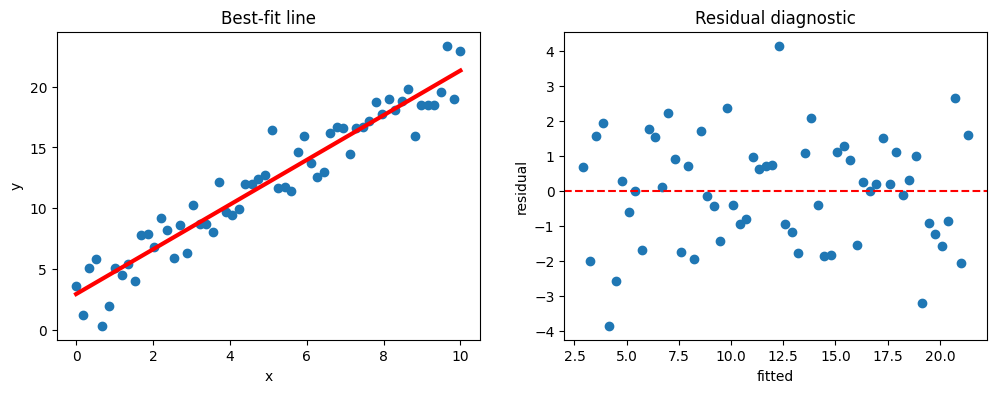

In [2]:
x=np.linspace(0,10,60); y=3+1.8*x+rng.normal(0,2,60); m=LinearRegression().fit(x[:,None],y); p=m.predict(x[:,None]); fig,ax=plt.subplots(1,2,figsize=(12,4)); ax[0].scatter(x,y); ax[0].plot(x,p,'r',lw=3); ax[0].set(title='Best-fit line',xlabel='x',ylabel='y'); ax[1].scatter(p,y-p); ax[1].axhline(0,color='r',ls='--'); ax[1].set(title='Residual diagnostic',xlabel='fitted',ylabel='residual'); plt.show()

Use a train/test split to estimate generalization. R² can be negative on unseen data when predictions are worse than the mean baseline.

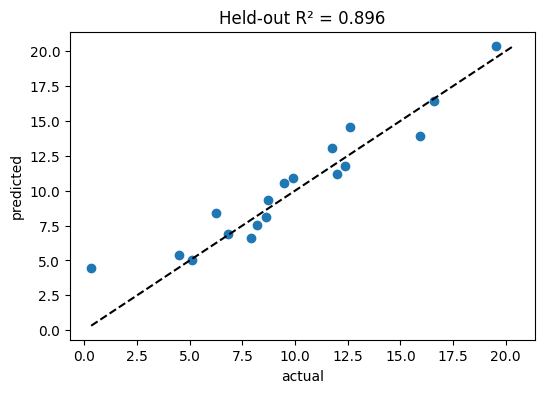

In [3]:
xt,xv,yt,yv=train_test_split(x[:,None],y,test_size=.3,random_state=4); m=LinearRegression().fit(xt,yt); pv=m.predict(xv); plt.figure(figsize=(6,4)); plt.scatter(yv,pv); lim=[min(yv.min(),pv.min()),max(yv.max(),pv.max())]; plt.plot(lim,lim,'k--'); plt.title(f'Held-out R² = {r2_score(yv,pv):.3f}'); plt.xlabel('actual'); plt.ylabel('predicted'); plt.show()